### Step 1 — Imports & Setup

In [1]:
import torch 
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

import os



### Step 2 — Define Transforms

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



### Step 3 — Load Dataset

In [4]:
train_dataset = torchvision.datasets.Food101(
    root="../data",
    split="train",
    transform=train_transform,
    download=False
)
test_dataset = torchvision.datasets.Food101(
    root="../data",
    split="test",
    transform=test_transform,
    download=False
)


In [5]:
print(len(train_dataset))
print(len(test_dataset))

75750
25250


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.64].


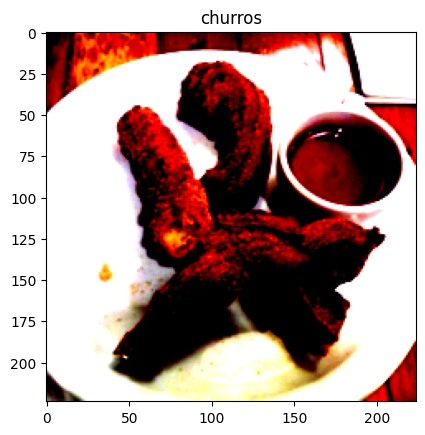

In [6]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]
plt.imshow(image.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.show()


In [9]:
from PIL import Image

img_path = "../data/food-101/images/churros/1004234.jpg"

try:
    img = Image.open(img_path)
    img.verify()
    print("Image is valid")
except Exception as e:
    print("Corrupted image:", e)

Image is valid


In [10]:
train_dataset.classes

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

### step 4: dataloaders


In [11]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(dataset=train_dataset,
                           batch_size=BATCH_SIZE,
                           shuffle=True,
                           num_workers=NUM_WORKERS,
                           pin_memory=True)


test_loaders = DataLoader(dataset=test_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)

### Step 5  class info

In [15]:
class_names = train_dataset.classes
class_to_idx =train_dataset.class_to_idx
num_classes = len(class_names)

In [16]:
print(f"Total classes: {num_classes}")

Total classes: 101


### Step 6: Sanity check

In [17]:
images , labels = next(iter(train_loader))

print(f"The image shape is {images.shape}") #[b,c,h,w] - [32 ,3,224,224]
print("Label shape:", labels.shape)
print("Sample labels:", labels[:5])

The image shape is torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Sample labels: tensor([71, 78, 34, 92, 23])


### Step 7 : Device Setup

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device = {device}")

Device = cuda
